In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel("../data/Superstore-final.xlsx")

print(df.head())

   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   South  FUR-BO-10

In [10]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()

print(f"Total Sales: {total_sales:,.2f}")
print(f"Total Profit: {total_profit:,.2f}")

Total Sales: 2,297,200.86
Total Profit: 286,397.02


In [11]:
profit_margin = (total_profit / total_sales) * 100

print(f"Profit Margin: {profit_margin:.2f}%")

Profit Margin: 12.47%


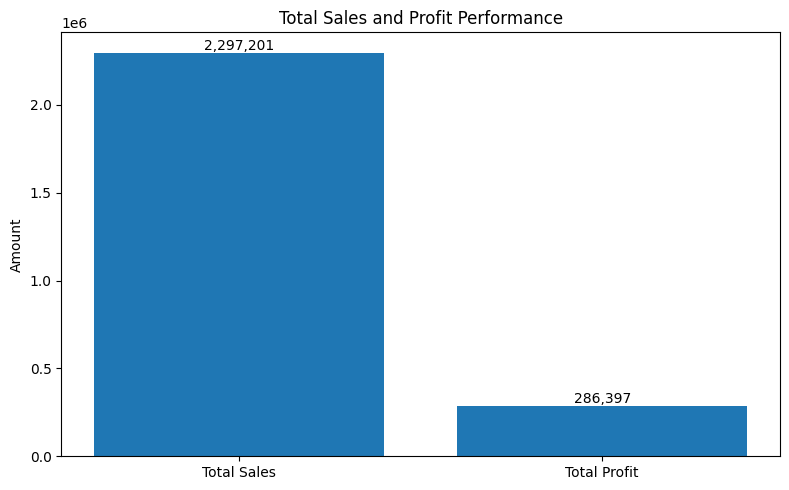

In [12]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()

# Data
metrics = ['Total Sales', 'Total Profit']
values = [total_sales, total_profit]

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(metrics, values)

# Show exact values on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:,.0f}',
        ha='center',
        va='bottom'
    )

plt.title('Total Sales and Profit Performance')
plt.ylabel('Amount')
plt.tight_layout()
plt.show()

In [15]:
print(df['Year'].unique())


[2016 2015 2014 2017]


In [18]:

# Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Extract Year
df['Year'] = df['Order Date'].dt.year

# Year-wise Sales and Profit
yearly_analysis = df.groupby('Year')[['Sales', 'Profit']].sum().reset_index()

# Calculate YoY Percentage Change
yearly_analysis['Sales Growth %'] = yearly_analysis['Sales'].pct_change() * 100
yearly_analysis['Profit Growth %'] = yearly_analysis['Profit'].pct_change() * 100

print(yearly_analysis.round(2))

   Year      Sales    Profit  Sales Growth %  Profit Growth %
0  2014  484247.50  49543.97             NaN              NaN
1  2015  470532.51  61618.60           -2.83            24.37
2  2016  609205.60  81795.17           29.47            32.74
3  2017  733215.26  93439.27           20.36            14.24


In [25]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
# Extract Year
df['Year'] = df['Order Date'].dt.year
# Year-wise Sales and Profit
yearly_analysis = df.groupby('Year')[['Sales', 'Profit']].sum().reset_index()

print(yearly_analysis)

   Year        Sales      Profit
0  2014  484247.4981  49543.9741
1  2015  470532.5090  61618.6037
2  2016  609205.5980  81795.1743
3  2017  733215.2552  93439.2696


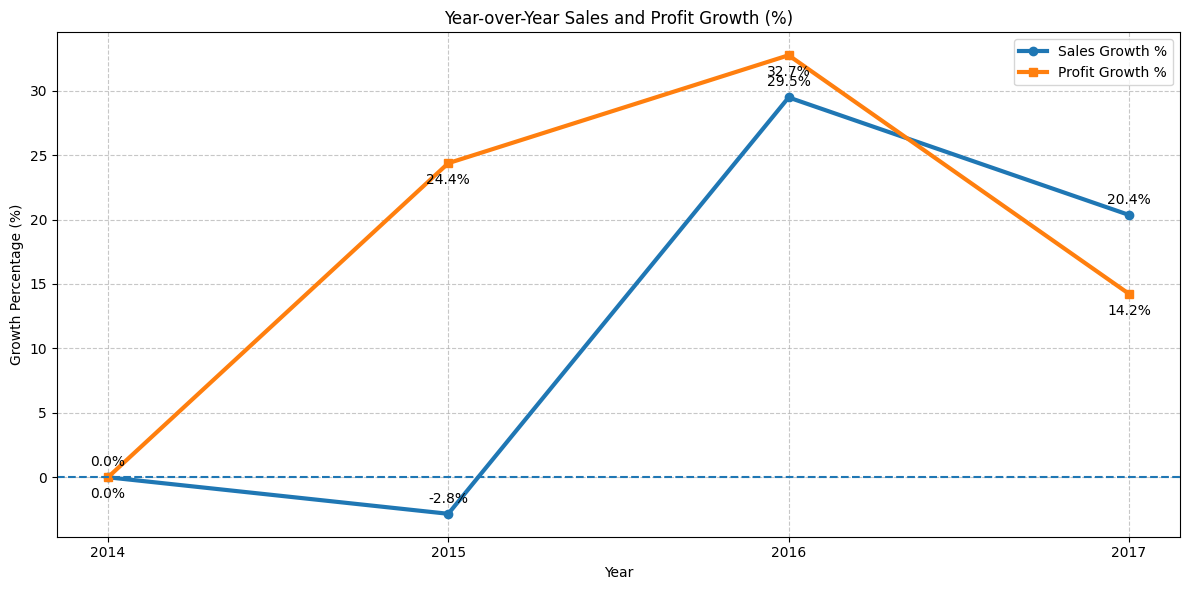

In [31]:
# Calculate Year-over-Year Growth Percentage
yearly_analysis['Sales Growth %'] = (
    yearly_analysis['Sales'].pct_change() * 100
)

yearly_analysis['Profit Growth %'] = (
    yearly_analysis['Profit'].pct_change() * 100
)

# Replace NaN in first year with 0
yearly_analysis.fillna(0, inplace=True)



# Plot Growth Trends
plt.figure(figsize=(12, 6))

plt.plot(
    yearly_analysis['Year'],
    yearly_analysis['Sales Growth %'],
    marker='o',
    linewidth=3,
    label='Sales Growth %'
)

plt.plot(
    yearly_analysis['Year'],
    yearly_analysis['Profit Growth %'],
    marker='s',
    linewidth=3,
    label='Profit Growth %'
)

# Add value labels
for x, y in zip(yearly_analysis['Year'], yearly_analysis['Sales Growth %']):
    plt.annotate(
        f'{y:.1f}%',
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha='center'
    )

for x, y in zip(yearly_analysis['Year'], yearly_analysis['Profit Growth %']):
    plt.annotate(
        f'{y:.1f}%',
        (x, y),
        textcoords="offset points",
        xytext=(0, -15),
        ha='center'
    )

plt.axhline(y=0, linestyle='--')

plt.title('Year-over-Year Sales and Profit Growth (%)')
plt.xlabel('Year')
plt.ylabel('Growth Percentage (%)')

plt.xticks(yearly_analysis['Year'])
plt.grid(True, linestyle='--', alpha=0.7)

plt.legend()
plt.tight_layout()

plt.show()

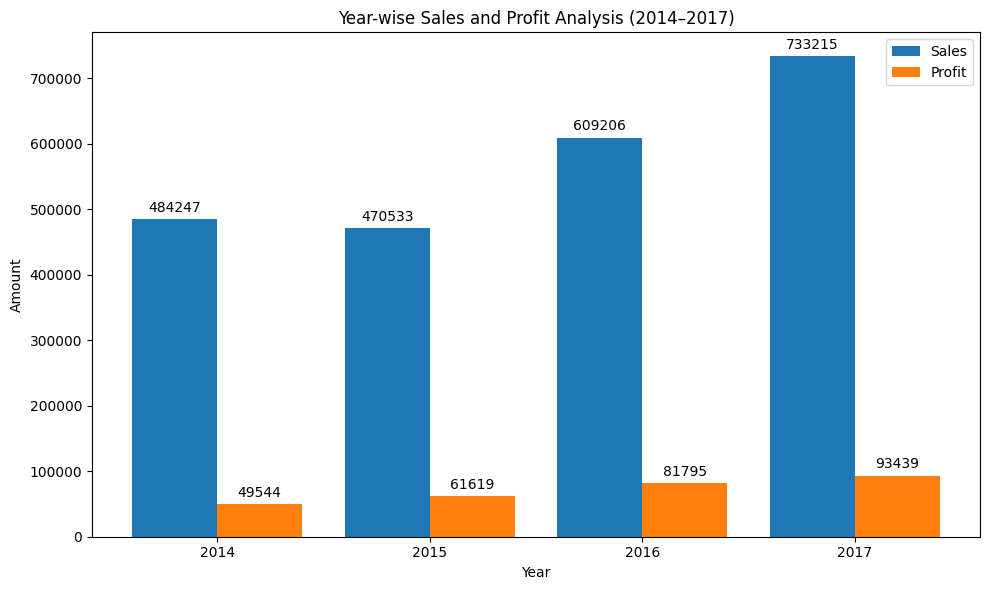

In [20]:
# Plot
plt.figure(figsize=(10, 6))

x = range(len(yearly_analysis))
width = 0.4

sales_bars = plt.bar(
    [i - width/2 for i in x],
    yearly_analysis['Sales'],
    width=width,
    label='Sales'
)

profit_bars = plt.bar(
    [i + width/2 for i in x],
    yearly_analysis['Profit'],
    width=width,
    label='Profit'
)

# Show exact values on bars
plt.bar_label(sales_bars, fmt='%.0f', padding=3)
plt.bar_label(profit_bars, fmt='%.0f', padding=3)

plt.xticks(x, yearly_analysis['Year'])
plt.title('Year-wise Sales and Profit Analysis (2014–2017)')
plt.xlabel('Year')
plt.ylabel('Amount')
plt.legend()
plt.tight_layout()

plt.show()

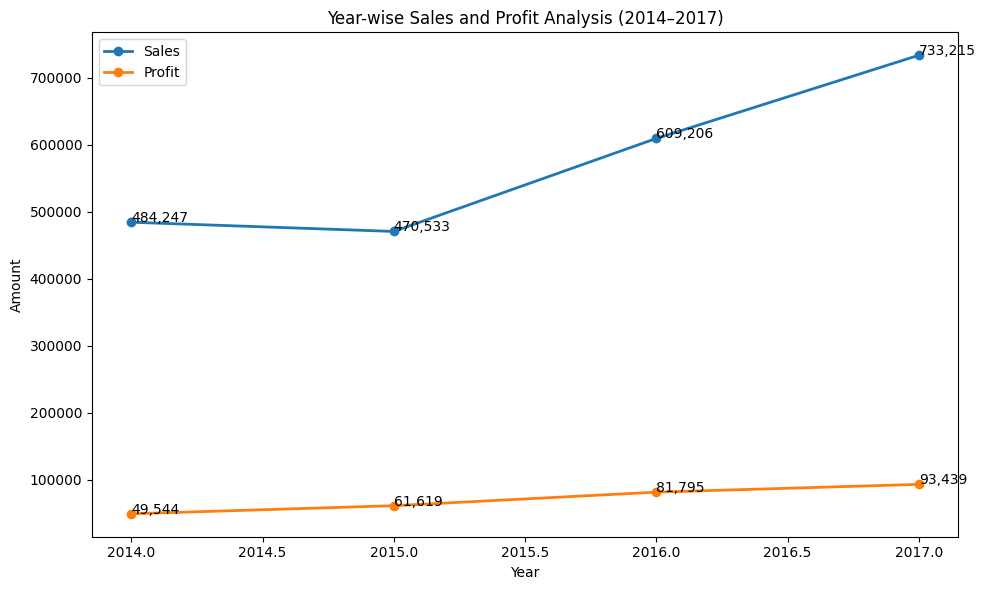

In [17]:
# Line Chart
plt.figure(figsize=(10, 6))

plt.plot(yearly_analysis['Year'],
         yearly_analysis['Sales'],
         marker='o',
         linewidth=2,
         label='Sales')

plt.plot(yearly_analysis['Year'],
         yearly_analysis['Profit'],
         marker='o',
         linewidth=2,
         label='Profit')

# Show exact values
for x, y in zip(yearly_analysis['Year'], yearly_analysis['Sales']):
    plt.text(x, y, f'{y:,.0f}')

for x, y in zip(yearly_analysis['Year'], yearly_analysis['Profit']):
    plt.text(x, y, f'{y:,.0f}')

plt.title('Year-wise Sales and Profit Analysis (2014–2017)')
plt.xlabel('Year')
plt.ylabel('Amount')
plt.legend()

plt.tight_layout()

plt.show()

In [32]:
import pandas as pd

# Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Extract Year and Month
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month_name()

# Month order
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

# Monthly Sales and Profit
monthly_analysis = (
    df.groupby(['Year', 'Month'])[['Sales', 'Profit']]
      .sum()
      .reset_index()
)

monthly_analysis['Month'] = pd.Categorical(
    monthly_analysis['Month'],
    categories=month_order,
    ordered=True
)

monthly_analysis = monthly_analysis.sort_values(['Year', 'Month'])

print(monthly_analysis.head())

   Year     Month      Sales     Profit
4  2014   January  14236.895  2450.1907
3  2014  February   4519.892   862.3084
7  2014     March  55691.009   498.7299
0  2014     April  28295.345  3488.8352
8  2014       May  23648.287  2738.7096


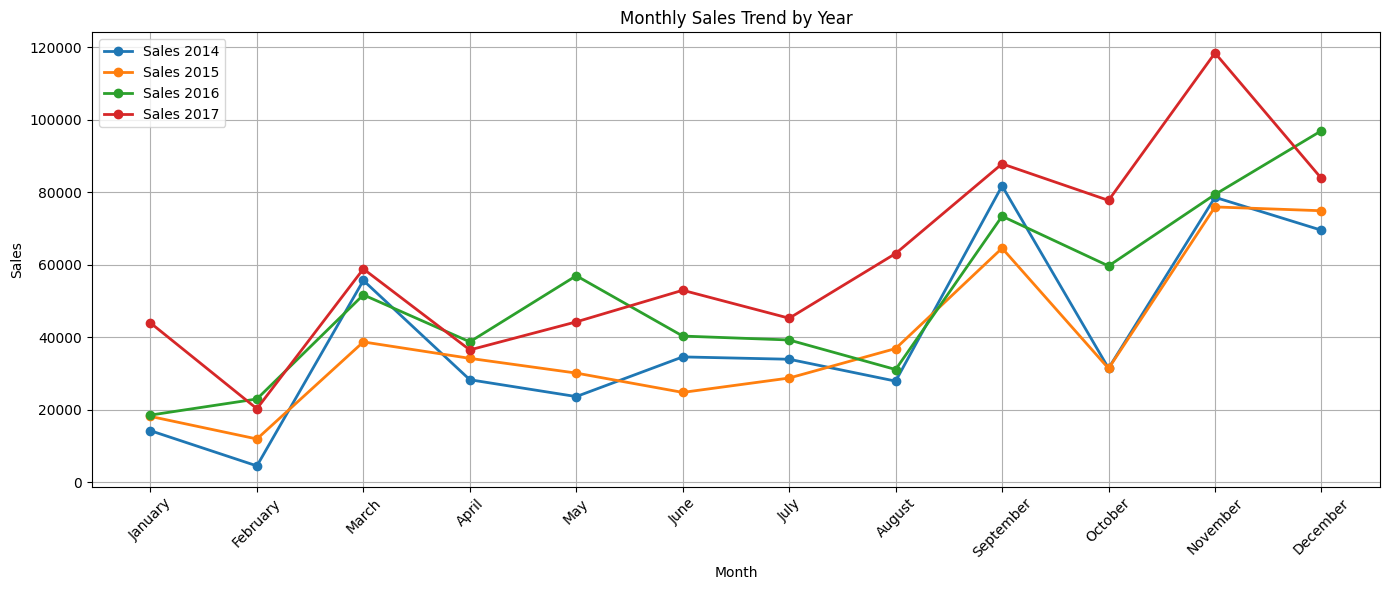

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

for year in sorted(monthly_analysis['Year'].unique()):
    data = monthly_analysis[monthly_analysis['Year'] == year]

    plt.plot(
        data['Month'],
        data['Sales'],
        marker='o',
        linewidth=2,
        label=f'Sales {year}'
    )

plt.title('Monthly Sales Trend by Year')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

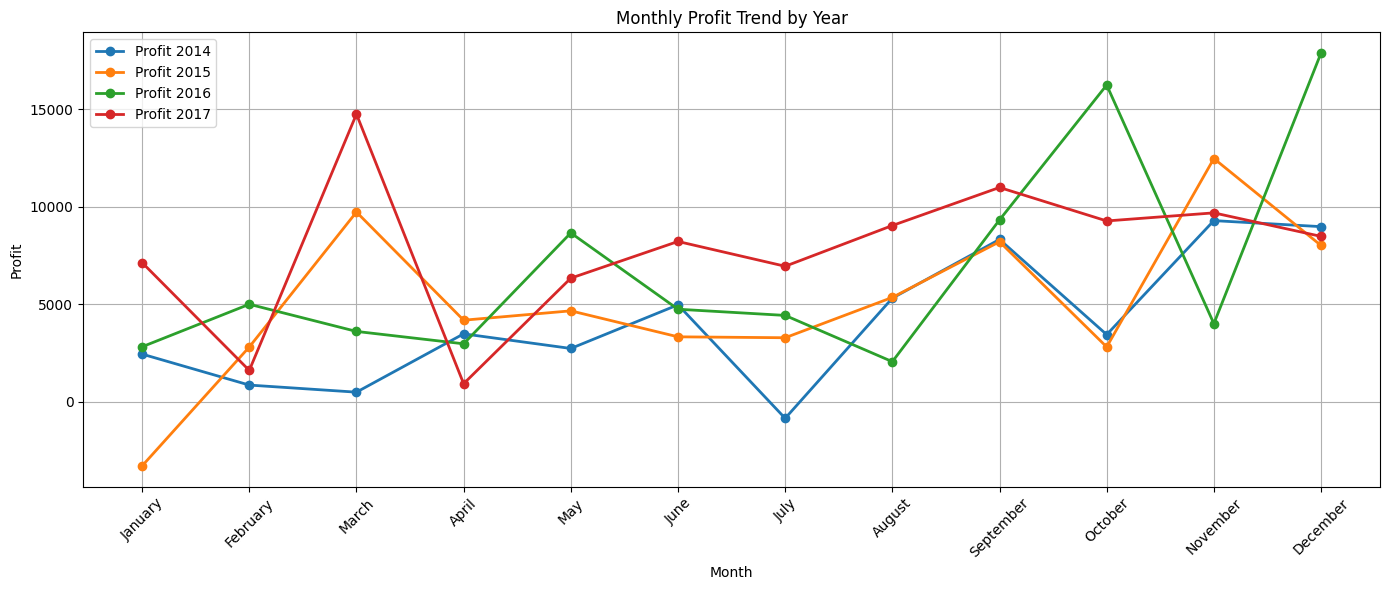

In [34]:
plt.figure(figsize=(14, 6))

for year in sorted(monthly_analysis['Year'].unique()):
    data = monthly_analysis[monthly_analysis['Year'] == year]

    plt.plot(
        data['Month'],
        data['Profit'],
        marker='o',
        linewidth=2,
        label=f'Profit {year}'
    )

plt.title('Monthly Profit Trend by Year')
plt.xlabel('Month')
plt.ylabel('Profit')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

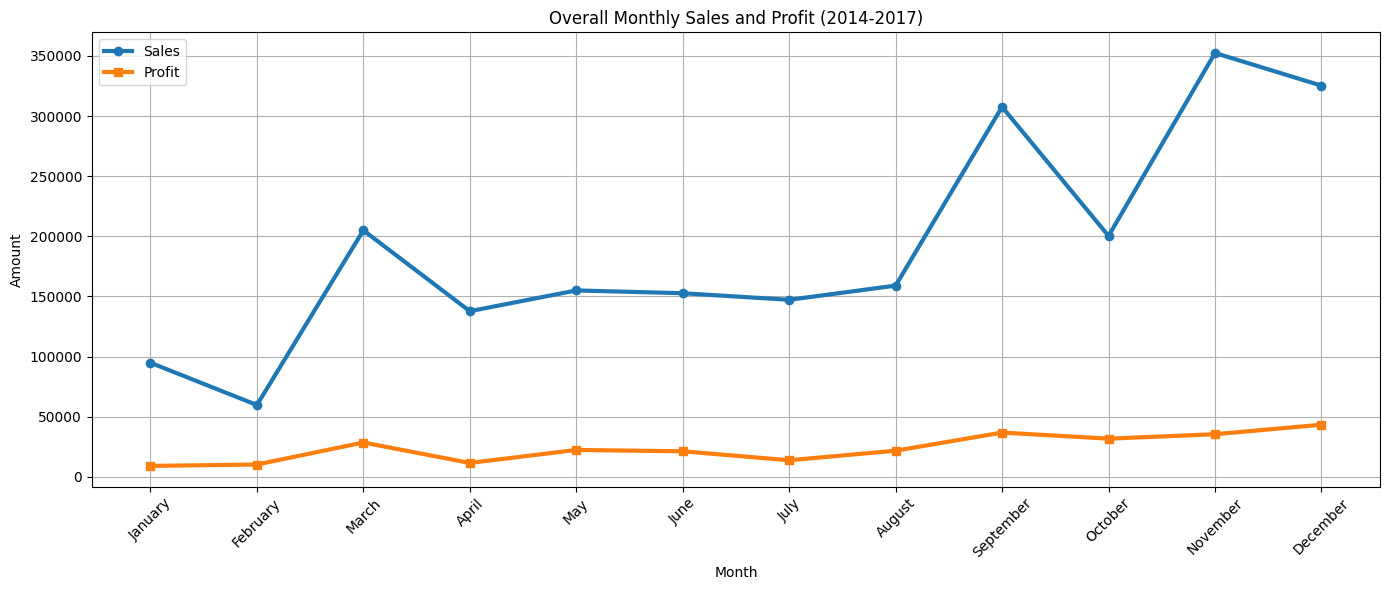

In [35]:
monthly_total = (
    df.groupby(df['Order Date'].dt.month_name())[['Sales', 'Profit']]
      .sum()
      .reindex(month_order)
      .reset_index()
)

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_total['Order Date'],
    monthly_total['Sales'],
    marker='o',
    linewidth=3,
    label='Sales'
)

plt.plot(
    monthly_total['Order Date'],
    monthly_total['Profit'],
    marker='s',
    linewidth=3,
    label='Profit'
)

plt.title('Overall Monthly Sales and Profit (2014-2017)')
plt.xlabel('Month')
plt.ylabel('Amount')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [36]:
region_analysis = (
    df.groupby('Region')[['Sales', 'Profit']]
      .sum()
      .reset_index()
      .sort_values(by='Sales', ascending=False)
)

print(region_analysis)

    Region        Sales       Profit
3     West  725457.8245  108418.4489
1     East  678781.2400   91522.7800
0  Central  501239.8908   39706.3625
2    South  391721.9050   46749.4303


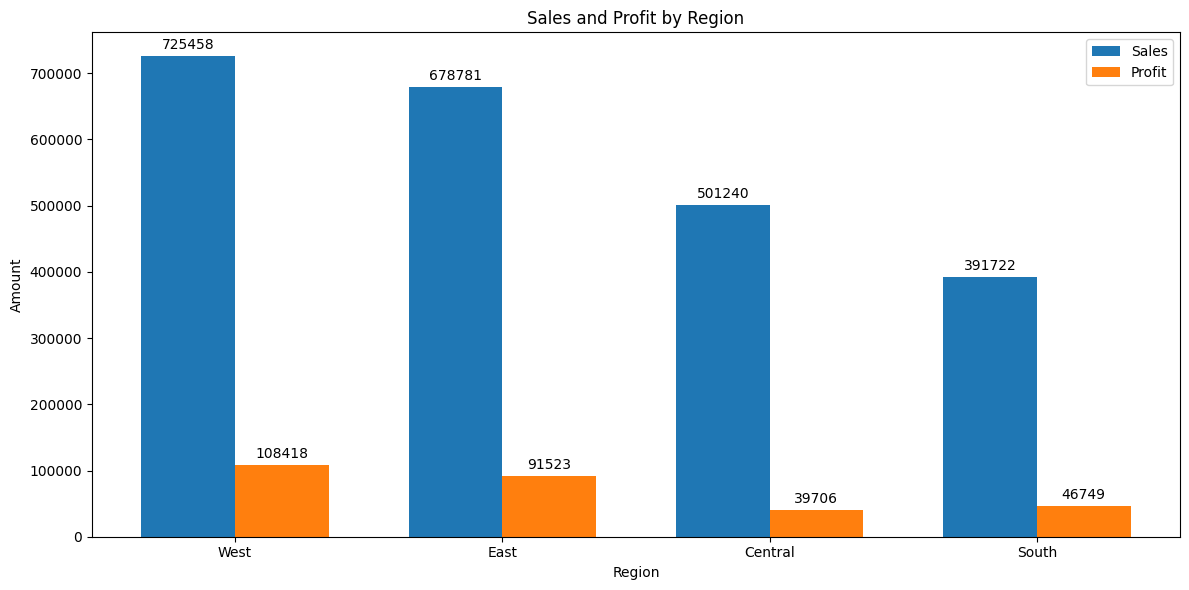

In [42]:
x = np.arange(len(region_analysis['Region']))
width = 0.35

plt.figure(figsize=(12, 6))

sales_bars = plt.bar(
    x - width/2,
    region_analysis['Sales'],
    width,
    label='Sales'
)

profit_bars = plt.bar(
    x + width/2,
    region_analysis['Profit'],
    width,
    label='Profit'
)

# Show exact values on bars
plt.bar_label(
    sales_bars,
    fmt='%.0f',
    padding=3
)

plt.bar_label(
    profit_bars,
    fmt='%.0f',
    padding=3
)

plt.xticks(x, region_analysis['Region'])

plt.title('Sales and Profit by Region')
plt.xlabel('Region')
plt.ylabel('Amount')
plt.legend()

plt.tight_layout()
plt.show()

In [45]:
category_analysis = (
    df.groupby('Category')[['Sales', 'Profit']]
      .sum()
      .reset_index()
      .sort_values(by='Sales', ascending=False)
)

print(category_analysis)

          Category        Sales       Profit
2       Technology  836154.0330  145454.9481
0        Furniture  741999.7953   18451.2728
1  Office Supplies  719047.0320  122490.8008


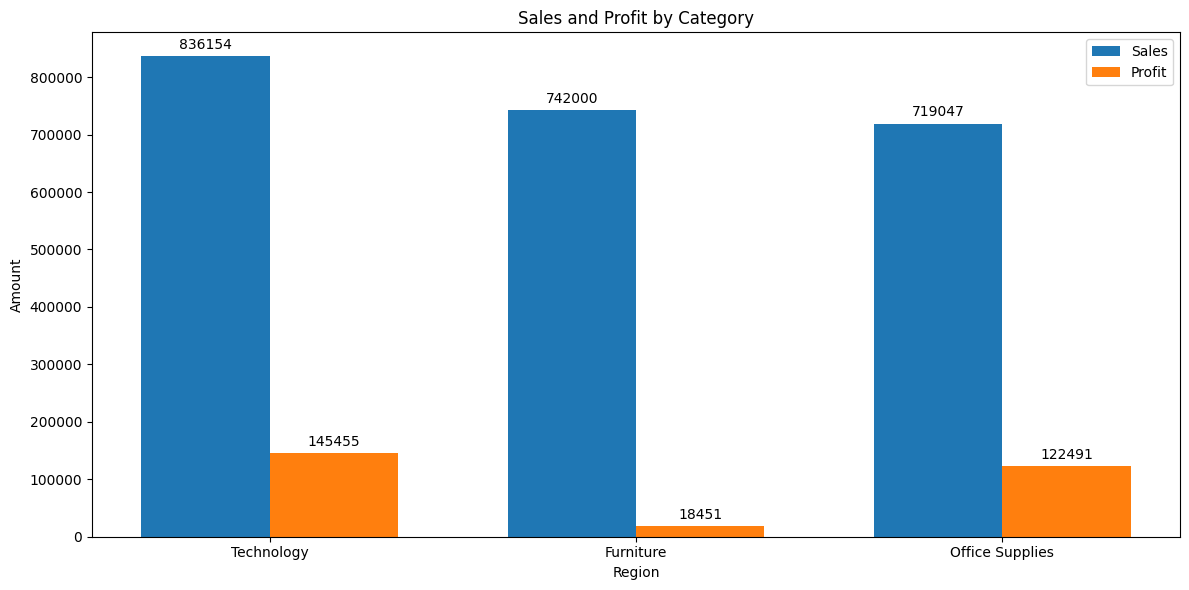

In [48]:
x = np.arange(len(category_analysis['Category']))
width = 0.35

plt.figure(figsize=(12, 6))

sales_bars = plt.bar(
    x - width/2,
    category_analysis['Sales'],
    width,
    label='Sales'
)

profit_bars = plt.bar(
    x + width/2,
    category_analysis['Profit'],
    width,
    label='Profit'
)

# Show exact values on bars
plt.bar_label(
    sales_bars,
    fmt='%.0f',
    padding=3
)

plt.bar_label(
    profit_bars,
    fmt='%.0f',
    padding=3
)

plt.xticks(x, category_analysis['Category'])

plt.title('Sales and Profit by Category')
plt.xlabel('Region')
plt.ylabel('Amount')
plt.legend()

plt.tight_layout()
plt.show()

In [71]:
subcategory_analysis = (
    df.groupby('Sub-Category')[['Sales', 'Profit']]
      .sum()
      .reset_index()
      .sort_values(by='Sales', ascending=False)
)

print(subcategory_analysis)

   Sub-Category        Sales      Profit
13       Phones  330007.0540  44515.7306
5        Chairs  328449.1030  26590.1663
14      Storage  223843.6080  21278.8264
16       Tables  206965.5320 -17725.4811
3       Binders  203412.7330  30221.7633
11     Machines  189238.6310   3384.7569
0   Accessories  167380.3180  41936.6357
6       Copiers  149528.0300  55617.8249
4     Bookcases  114879.9963  -3472.5560
1    Appliances  107532.1610  18138.0054
9   Furnishings   91705.1640  13059.1436
12        Paper   78479.2060  34053.5693
15     Supplies   46673.5380  -1189.0995
2           Art   27118.7920   6527.7870
7     Envelopes   16476.4020   6964.1767
10       Labels   12486.3120   5546.2540
8     Fasteners    3024.2800    949.5182


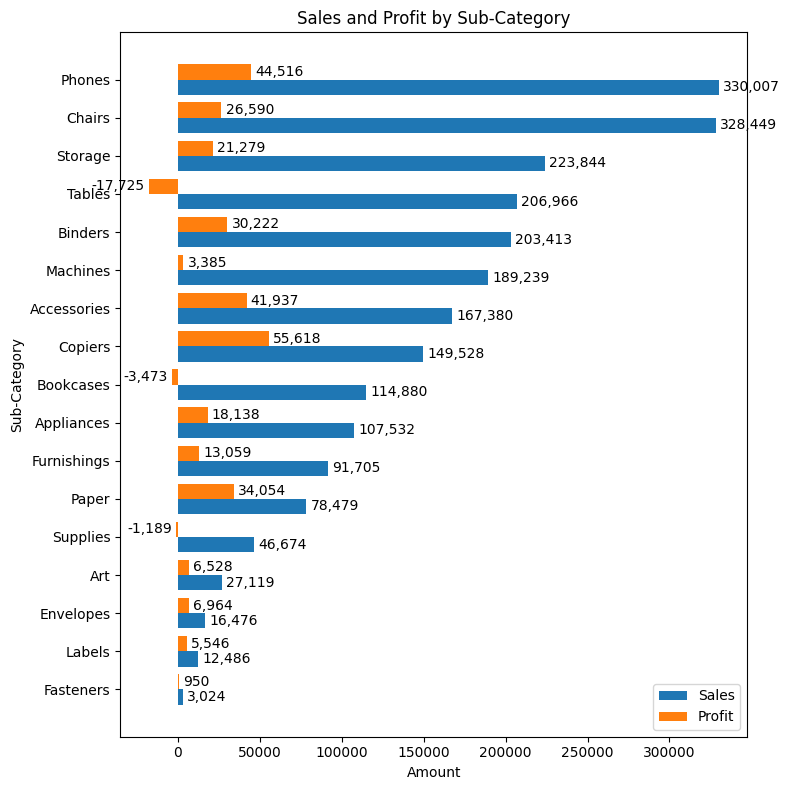

In [81]:
subcategory_analysis = subcategory_analysis.sort_values(
    by='Sales',
    ascending=True
)

y = np.arange(len(subcategory_analysis))
height = 0.4

plt.figure(figsize=(8,8))

sales_bars = plt.barh(
    y - height/2,
    subcategory_analysis['Sales'],
    height,
    label='Sales'
)

profit_bars = plt.barh(
    y + height/2,
    subcategory_analysis['Profit'],
    height,
    label='Profit'
)

# Add exact values
plt.bar_label(
    sales_bars,
    labels=[f'{v:,.0f}' for v in subcategory_analysis['Sales']],
    padding=3
)

plt.bar_label(
    profit_bars,
    labels=[f'{v:,.0f}' for v in subcategory_analysis['Profit']],
    padding=3
)

plt.yticks(y, subcategory_analysis['Sub-Category'])

plt.title('Sales and Profit by Sub-Category')
plt.xlabel('Amount')
plt.ylabel('Sub-Category')
plt.legend()

plt.tight_layout()
plt.show()

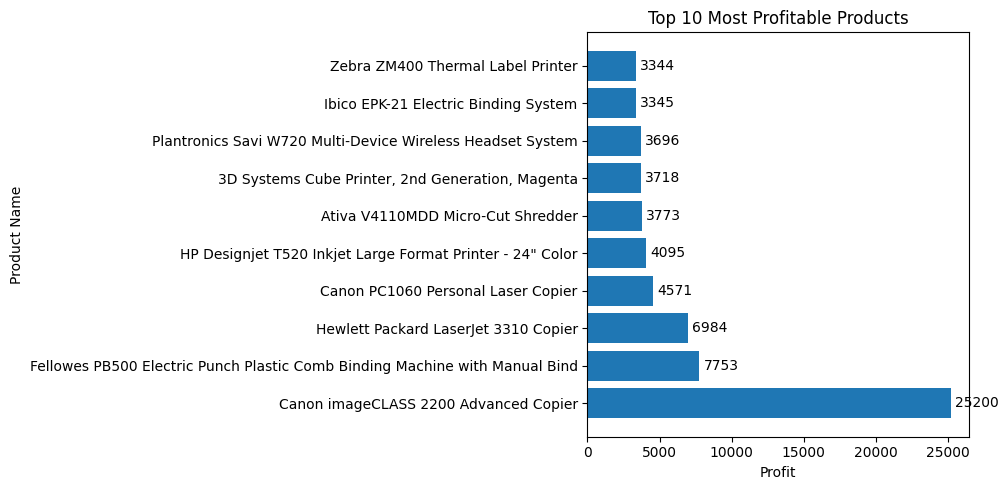

In [53]:
# Top 10 Most Profitable Products
top_profit_products = (
    df.groupby('Product Name')['Profit']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)



# Visualization
plt.figure(figsize=(10,5))

bars = plt.barh(
    top_profit_products['Product Name'],
    top_profit_products['Profit']
)

plt.bar_label(
    bars,
    fmt='%.0f',
    padding=3
)

plt.title('Top 10 Most Profitable Products')
plt.xlabel('Profit')
plt.ylabel('Product Name')

plt.tight_layout()
plt.show()

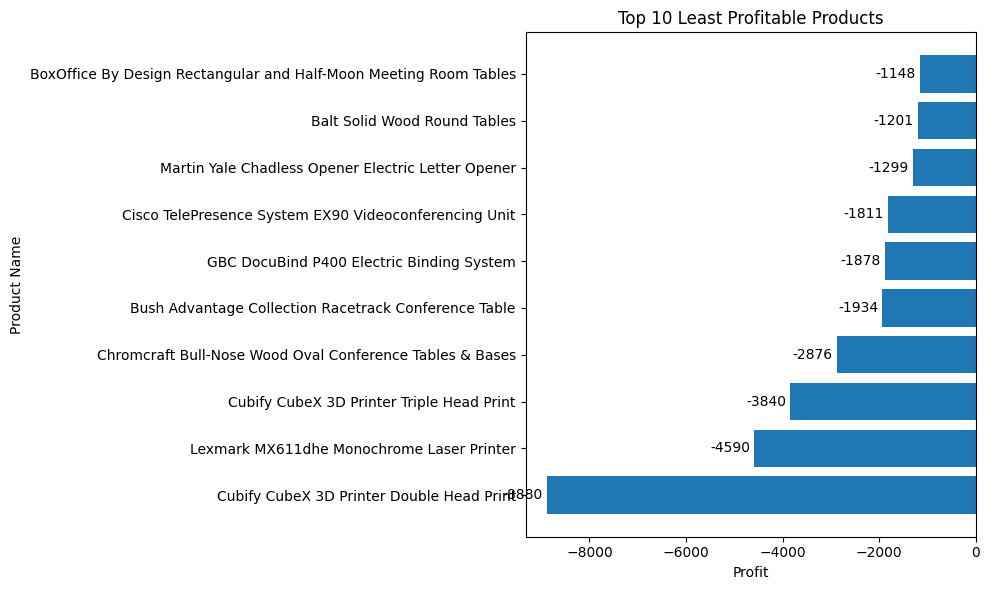

In [70]:
# Top 10 Least Profitable Products
least_profit_products = (
    df.groupby('Product Name')['Profit']
      .sum()
      .sort_values()
      .head(10)
      .reset_index()
)


# Visualization
plt.figure(figsize=(10,6))

bars = plt.barh(
    least_profit_products['Product Name'],
    least_profit_products['Profit']
)

plt.bar_label(
    bars,
    fmt='%.0f',
    padding=3
)

plt.title('Top 10 Least Profitable Products')
plt.xlabel('Profit')
plt.ylabel('Product Name')

plt.tight_layout()
plt.show()

In [82]:
segment_sales_profit = (
    df.groupby('Segment')
      .agg(
          Sales=('Sales', 'sum'),
          Profit=('Profit', 'sum')
      )
      .reset_index()
)

print(segment_sales_profit)

       Segment         Sales       Profit
0     Consumer  1.161401e+06  134119.2092
1    Corporate  7.061464e+05   91979.1340
2  Home Office  4.296531e+05   60298.6785


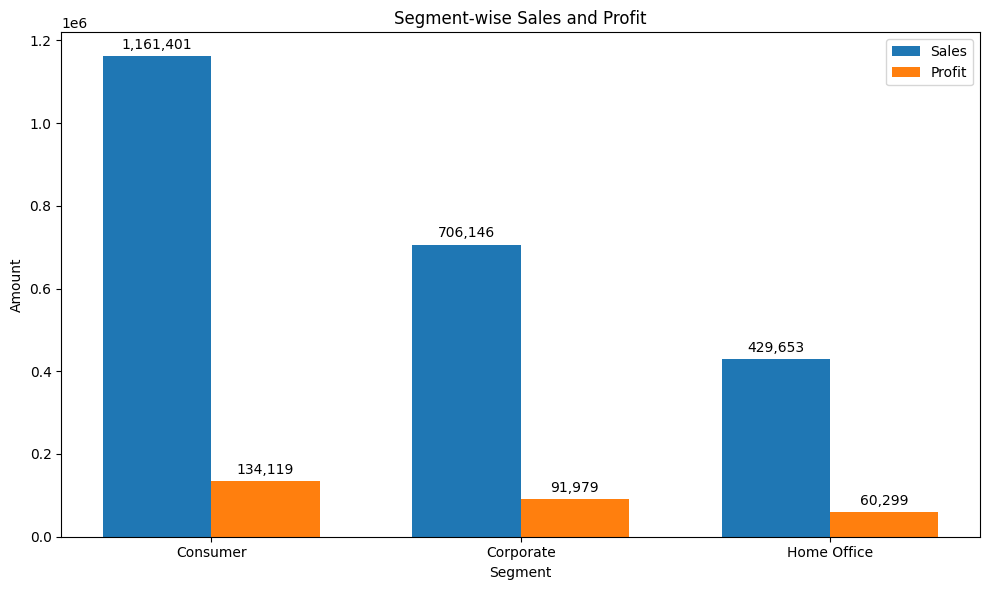

In [83]:
x = np.arange(len(segment_sales_profit['Segment']))
width = 0.35

plt.figure(figsize=(10,6))

sales_bars = plt.bar(
    x - width/2,
    segment_sales_profit['Sales'],
    width,
    label='Sales'
)

profit_bars = plt.bar(
    x + width/2,
    segment_sales_profit['Profit'],
    width,
    label='Profit'
)

# Show exact values
plt.bar_label(
    sales_bars,
    labels=[f'{v:,.0f}' for v in segment_sales_profit['Sales']],
    padding=3
)

plt.bar_label(
    profit_bars,
    labels=[f'{v:,.0f}' for v in segment_sales_profit['Profit']],
    padding=3
)

plt.xticks(x, segment_sales_profit['Segment'])

plt.title('Segment-wise Sales and Profit')
plt.xlabel('Segment')
plt.ylabel('Amount')
plt.legend()

plt.tight_layout()
plt.show()